# RecSys МАГОЛЕГО, ФКН ВШЭ

## Домашняя работа 2 (Часть 1): Graph Laplacian

### Оценивание и штрафы
Всего заданий: **7**, максимальная оценка — **6 баллов (+1.5 бонус)**.

Задание выполняется самостоятельно. «Похожие» решения считаются плагиатом и все задействованные студенты (в том числе те, у кого списали) не могут получить за него больше 0 баллов. Весь код должен быть написан самостоятельно. Чужим кодом пользоваться запрещается,даже с указанием ссылки на источник. В разумных рамках, конечно. Взять пару очевидных строчек кода для реализации какого-то небольшого функционала можно.

Неэффективная реализация кода может негативно отразиться на оценке (например, лишние циклы, `np.vectorize`, `np.apply_along_axis` и так далее). Также оценка может быть снижена за плохо читаемый код и плохо оформленные графики. Все ответы должны сопровождаться кодом или комментариями о том, как они были получены.

Использование генеративных языковых моделей разрешено только в случае явного указания на это. Необходимо прописать (в соответствующих пунктах, где использовались, либо в начале/конце работы):

- какая языковая модель использовалась
- какие использовались промпты и в каких частях работы
- с какими сложностями вы столкнулись при использовании генеративных моделей, с чем они помогли больше всего
  
Copy-paste ответа генеративной модели запрещается (кроме графиков, но все равно нужно явно прописывать использование)

**Дедлайн: 15.03.2026 23:59 (по МСК)**

**Сдавать сюда: [Классрум](https://classroom.google.com/c/ODQzNjI1ODIzMDEy/a/ODQ2ODc0NzExMTI5/details)**

### О задании
В данном домашнем задании вы реализуете алгоритмы рекомендаций на Graph Laplacian для построения эмбеддингов и обучите supervised модель на датасете Yahoo! Movies.

P.S Пожалуйста, аккуратно оформляйте графики, ориентироваться можно на [это](https://github.com/esokolov/ml-course-hse/blob/master/2022-fall/seminars/sem02-charts.ipynb). У графиков обязательно должно быть:

- Название
- Подписанные оси
- Легенда, если необходимо (например, если несколько графиков на одном рисунке)
- Все должно быть четко видно и ничего не сливаться
- За некрасивые графики можем снизить баллы

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

## Структура датасета

Датасет можете скачать по [ссылке](https://drive.google.com/file/d/1PsAL83MQnvQuTpjrNXs8CiPpOeSGcUL-/view?usp=share_link)

Датасет состоит из 6 основных файлов. Все данные представлены в текстовом формате, где колонки разделены символом табуляции `\t`.

### 1. Оценки пользователей
В этих файлах содержатся оценки фильмов пользователей
-  **Файлы:** `ydata-ymovies-user-movie-ratings-train-v1_0` и `ydata-ymovies-user-movie-ratings-test-v1_0`
- **Поля:**
  * User ID
  * Movie ID
  * Rating_13: от 1 (F) до 13 (A+)
  * Rating_5: упрощенная шкала от 1 до 5



### 2. Демография пользователей
Информация про аудиторию

- **Файл:** `ydata-ymovies-user-demographics-v1_0`
- **Поля:**
  * User ID
  * Year of birth
  * Sex (`m`/`f`)

### 3. Описание фильмов
Метаданные фильмов
* **Файл:** `ydata-ymovies-movie-content-descr-v1_0`
* **Что внутри:** Название, синопсис, жанры, режиссеры, актеры, количество наград, средняя оценка критиков и даже ссылки на постеры.
* **Важно:** Если данных нет, стоит заглушка `\N`. Если в поле несколько значений (например, список актеров), они разделены символом `|`.

### 4. Списки соответствия
Файлы `mapping-to-movielens` и `mapping-to-eachmovie` позволяют связать ID фильмов Yahoo с другими популярными датасетами (MovieLens и EachMovie). Это полезно, если вы хотите объединить данные из разных источников


### Graph Laplacian

В этой части мы будем использовать строить эмбеддинги пользователей и фильмов с помощью графа Лапласиана, чтобы потом на этих эмбеддингах обучать supervised модель, которая уже будет рекомендовать фильмы

**Задание 0 (1 балл):** Загрузите необходимые данные и постройте неориентированный невзвешенный двудольный граф. Ребро между пользователем $u$ и фильмом $i$ существует, если пользователь поставил фильму любую оценку. Сформируйте матрицу смежности $A$ (не забудьте использовать разреженные матрицы)

In [7]:
from scipy.sparse import csr_matrix, eye, diags
from scipy.sparse.linalg import eigsh

train = pd.read_csv("ydata-ymovies-user-movie-ratings-train-v1_0.txt.gz", sep="\t", header=None, names=["uid","mid","r13","r5"])
test  = pd.read_csv("ydata-ymovies-user-movie-ratings-test-v1_0.txt.gz",  sep="\t", header=None, names=["uid","mid","r13","r5"])

# одна дуга на пару (user, movie) — граф невзвешенный
train = train.drop_duplicates(subset=["uid", "mid"])

us = sorted(train["uid"].unique())
ms = sorted(train["mid"].unique())
nu, nm = len(us), len(ms)
u2i = {u:i for i,u in enumerate(us)}
m2i = {m:i for i,m in enumerate(ms)}
N = nu + nm

ui = train["uid"].map(u2i).values
mi = train["mid"].map(m2i).values + nu
r  = np.concatenate([ui, mi])
c  = np.concatenate([mi, ui])
A  = csr_matrix((np.ones(len(r)), (r, c)), shape=(N, N))
A.sum_duplicates()
print(f"nu={nu}, nm={nm}, N={N}, nnz={A.nnz}")

nu=7642, nm=11916, N=19558, nnz=422462


**Задание 1 (1 балл):** На основе матрицы $A$ вычислите диагональную матрицу степеней $D$ и постройте нормализованный Лапласиан граф:

$$
L_{sym} = I - D^{-1/2} A D^{-1/2}
$$

Найдите $d$ (например, $d=64$) собственных вектора матрицы $L_{sym}$, соответствующих ее наименьшим собственным значениям. Не забудьте убрать самый первый вектор (почему?). Полученные вектора будем использовать в качестве признаков

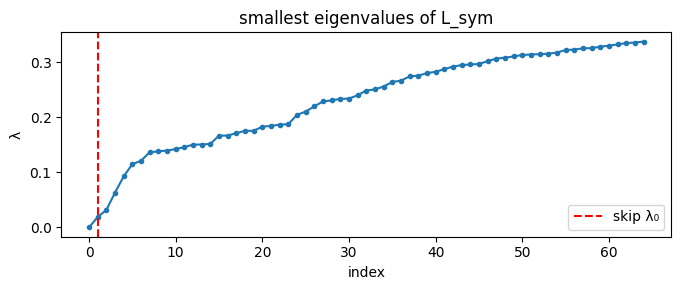

In [8]:
d = 64
deg = np.asarray(A.sum(1)).flatten()
dis = np.where(deg > 0, deg**-0.5, 0.)
Dis = diags(dis)
Ls  = eye(N, format="csr") - Dis @ A @ Dis

vals, vecs = eigsh(Ls, k=d+1, which="SM", tol=1e-4, maxiter=3000)
idx  = np.argsort(vals)
vals, vecs = vals[idx], vecs[:, idx]
# первый собственный вектор соответствует λ≈0 (константный), не несёт информации о структуре графа
emb  = vecs[:, 1:]
ue   = emb[:nu]
ie   = emb[nu:]

fig, ax = plt.subplots(figsize=(7, 3))
ax.plot(vals, marker="o", ms=3)
ax.set_title("smallest eigenvalues of L_sym")
ax.set_xlabel("index"); ax.set_ylabel("λ")
ax.axvline(1, color="red", ls="--", label="skip λ₀")
ax.legend(); plt.tight_layout(); plt.show()

**Задание 2 (0.5 балла):** Модель должна понимать, какие фильмы релевантны, а какие нет. Поэтому необходимо также добавить к существующим тренировочным данным примеры нулевого класса (negative sampling)

Сгенерируйте негативные примеры (класс 0), случайно выбирая пары «пользователь-фильм», которых нет в тренировочных данных. Рекомендуемая пропорция негативных к позитивным примерам — 2:1 или 3:1

Создайте итоговую матрицу признаков $X$. Для каждой пары $(u,i)$ сформируйте вектор признаков, объединив эмбеддинг пользователя и эмбеддинг фильма (например, через конкатенацию). Вектор ответов y должен состоять из бинарных меток (1 и 0).

In [9]:
rng = np.random.default_rng(42)
tr_set = set(zip(train["uid"].values, train["mid"].values))
pu = train["uid"].map(u2i).values
pm = train["mid"].map(m2i).values
np_, ratio = len(pu), 2
nn_ = ratio * np_

nu_s, nm_s = [], []
while len(nu_s) < nn_:
    bu = rng.integers(0, nu, size=nn_*2)
    bm = rng.integers(0, nm, size=nn_*2)
    for a, b in zip(bu, bm):
        if (us[a], ms[b]) not in tr_set:
            nu_s.append(a); nm_s.append(b)
        if len(nu_s) >= nn_: break
nu_s = np.array(nu_s[:nn_]); nm_s = np.array(nm_s[:nn_])

au = np.concatenate([pu, nu_s])
am = np.concatenate([pm, nm_s])
y  = np.concatenate([np.ones(np_), np.zeros(nn_)])
X  = np.hstack([ue[au], ie[am]])
print(f"X={X.shape}, y={np.bincount(y.astype(int))}")

X=(633693, 128), y=[422462 211231]


**Задание 3 (1 балл):** Пришло время обучить модель на наших признаках:

- Выберите межу `RandomForestClassifier` и `GradientBoostingClassifier`
- Предсказывайте вероятность, что фильм понравится пользователю
- Провалидируйте вашу модель на тестовом датасете с метриками из ДЗ-1

In [10]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

def p_k(a,p,k): return len(set(p[:k])&set(a))/k
def r_k(a,p,k): return len(set(p[:k])&set(a))/max(len(a),1)
def ndcg(a,p,k):
    s=set(a); dc=sum(1/np.log2(i+2) for i,x in enumerate(p[:k]) if x in s)
    ic=sum(1/np.log2(i+2) for i in range(min(len(a),k))); return dc/ic if ic else 0.
def apk(a,p,k):
    s=set(a); h=0; v=0.
    for i,x in enumerate(p[:k]):
        if x in s: h+=1; v+=h/(i+1)
    return v/max(min(k, len(a)), 1)

K = 10
Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.1, random_state=42, stratify=y)
clf = RandomForestClassifier(n_estimators=100, max_depth=8, n_jobs=-1, random_state=42)
clf.fit(Xtr, ytr)

tp_test = test[test["mid"].isin(set(ms)) & test["uid"].isin(set(us))]
tu = tp_test["uid"].unique()

ps, rs, ns_, ms_ = [], [], [], []
for uid in tu:
    ui_ = u2i.get(uid)
    if ui_ is None: continue
    act = tp_test[(tp_test["uid"]==uid) & (tp_test["r5"] >= 4)]["mid"].map(m2i).dropna().astype(int).tolist()
    if not act: continue
    ft = np.hstack([np.tile(ue[ui_], (nm,1)), ie])
    sc = clf.predict_proba(ft)[:,1]
    rk = np.argsort(-sc).tolist()
    ps.append(p_k(act,rk,K)); rs.append(r_k(act,rk,K))
    ns_.append(ndcg(act,rk,K)); ms_.append(apk(act,rk,K))

print(f"p@{K}={np.mean(ps):.4f}  r@{K}={np.mean(rs):.4f}  ndcg@{K}={np.mean(ns_):.4f}  map@{K}={np.mean(ms_):.4f}")

p@10=0.0158  r@10=0.0472  ndcg@10=0.0351  map@10=0.0201


**Задание 4 (1 балл):** Добавьте к вашим графовым признакам метаданные из файлов `ydata-ymovies-user-demographics` и `ydata-ymovies-movie-content-descr`. Замерьте, насколько изменились метрики после обогащения модели этими признаками

In [12]:
demo = pd.read_csv("ydata-ymovies-user-demographics-v1_0.txt.gz", sep="\t", header=None, names=["uid","year","sex"])
mcols = ["movie_id","title","synopsis","running_time","mpaa_rating","mpaa_reasons",
         "release_date_txt","release_date","distributor","poster_url","genres","directors",
         "director_ids","crew","crew_ids","crew_types","actors","actor_ids","avg_critic_rating",
         "num_critic_ratings","awards_won","awards_nominated","awards_won_list","awards_nominated_list",
         "movie_mom_rating","movie_mom_review","review_summaries","review_owners","trailer_captions",
         "greg_preview_url","dvd_review_url","gnpp","avg_user_rating","num_user_ratings"]
mm = pd.read_csv("ydata-ymovies-movie-content-descr-v1_0.txt.gz", sep="\t", header=None,
                 names=mcols, na_values="\\N", encoding="latin-1")

demo["sb"] = (demo["sex"]=="m").astype(float)
demo["yr"] = pd.to_numeric(demo["year"], errors="coerce")
demo["bn"] = (demo["yr"].fillna(demo["yr"].median())-1900)/100
ufd = demo.set_index("uid")[["sb","bn"]]

nc = ["running_time","avg_critic_rating","num_critic_ratings","awards_won",
      "awards_nominated","avg_user_rating","num_user_ratings"]
for c in nc: mm[c] = pd.to_numeric(mm[c], errors="coerce")
from sklearn.preprocessing import StandardScaler
scl = StandardScaler()
mn = scl.fit_transform(mm[nc].fillna(0).values)
mfd = pd.DataFrame(mn, index=mm["movie_id"].values, columns=nc)

uf_arr = np.array([ufd.loc[us[u]].values if us[u] in ufd.index else np.zeros(2) for u in range(nu)])
mf_arr = np.array([mfd.loc[ms[m]].values if ms[m] in mfd.index else np.zeros(len(nc)) for m in range(nm)])

Xa = np.hstack([ue[au], ie[am], uf_arr[au], mf_arr[am]])
Xtr2, Xte2, ytr2, _ = train_test_split(Xa, y, test_size=0.1, random_state=42, stratify=y)
clf2 = RandomForestClassifier(n_estimators=100, max_depth=8, n_jobs=-1, random_state=42)
clf2.fit(Xtr2, ytr2)

ps2, rs2, ns2, ms2 = [], [], [], []
for uid in tu:
    ui_ = u2i.get(uid)
    if ui_ is None: continue
    act = tp_test[(tp_test["uid"]==uid) & (tp_test["r5"] >= 4)]["mid"].map(m2i).dropna().astype(int).tolist()
    if not act: continue
    ft = np.hstack([np.tile(ue[ui_], (nm,1)), ie,
                    np.tile(uf_arr[ui_], (nm,1)), mf_arr])
    sc_ = clf2.predict_proba(ft)[:,1]
    rk = np.argsort(-sc_).tolist()
    ps2.append(p_k(act,rk,K)); rs2.append(r_k(act,rk,K))
    ns2.append(ndcg(act,rk,K)); ms2.append(apk(act,rk,K))

print(f"p@{K}={np.mean(ps2):.4f}  r@{K}={np.mean(rs2):.4f}  ndcg@{K}={np.mean(ns2):.4f}  map@{K}={np.mean(ms2):.4f}")
print(f"Δndcg={np.mean(ns2)-np.mean(ns_):+.4f}  Δmap={np.mean(ms2)-np.mean(ms_):+.4f}")

p@10=0.0158  r@10=0.0465  ndcg@10=0.0345  map@10=0.0193
Δndcg=-0.0006  Δmap=-0.0008


**Задание 5:** Давайте сделаем нашу модель более продвинутой и точной. Для этого вам предстоит реализовать следующие улучшения:

**1. Взвешенный граф взаимодействий (0.5 балла)**

Сейчас мы рассматриваем только сам факт взаимодействия (оценил / не оценил). Однако значения оценок несут в себе много полезной информации!

Вместо единиц в матрице смежности $A$ используйте нормализованные значения из колонки с рейтингами

**2. Сэмплинг «сложных» негативных примеров (Hard Negative Sampling) (0.5 балла)**

Генерация случайных негативных примеров (Uniform Negative Sampling) — это хороший старт. Но случайный несмотренный фильм может оказаться никому не известным артхаусом, и модели будет слишком легко отличить его от популярных просмотренных блокбастеров

Реализуйте сэмплинг сложных негативных примеров. Например, предлагайте в качестве нулей фильмы, которые очень популярны во всем датасете, но данный конкретный пользователь их так и не посмотрел

**3. Эксперименты с объединением эмбеддингов (0.5 балла)**

То, как именно мы объединяем эмбеддинг пользователя $E_u$ и фильма $E_i$, критически влияет на качество обучения модели

Сравните разные способы формирования итогового вектора признаков для пары $(u, i)$:
  - Конкатенация: $[E_u, E_i]$
  - Поэлементное умножение (Hadamard product): $E_u \odot E_i$
  - Косинусная близость: Скалярное произведение нормализованных векторов

На каждый пункт дайте ответ, как изменились метрики рекомендаций / качество собственных векторов? Без анализа баллы не засчитаются!

concat-uniform            ndcg@10=0.0211
concat-hard               ndcg@10=0.0217
hadamard-uniform          ndcg@10=0.0197
cosine-uniform            ndcg@10=0.0041
concat-weighted           ndcg@10=0.0204


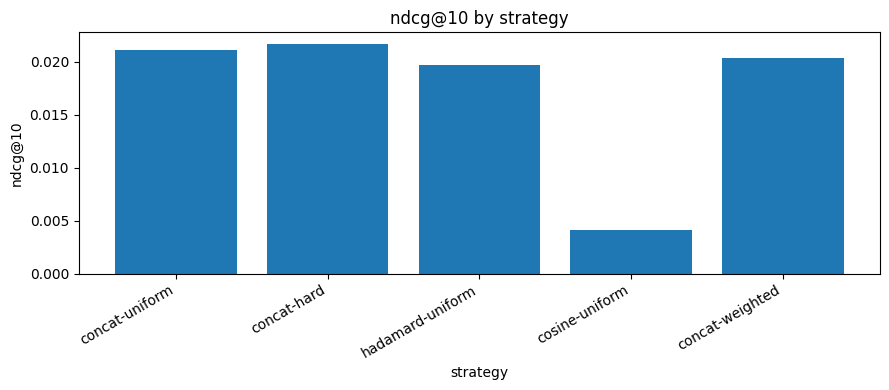

In [13]:
r_min, r_max = train["r5"].min(), train["r5"].max()
w = (train["r5"].values - r_min) / (r_max - r_min + 1e-9)
uw = train["uid"].map(u2i).values; mw = train["mid"].map(m2i).values + nu
rw = np.concatenate([uw, mw]); cw = np.concatenate([mw, uw]); dw = np.concatenate([w, w])
Aw = csr_matrix((dw, (rw, cw)), shape=(N, N)); Aw.sum_duplicates()
dw2 = np.asarray(Aw.sum(1)).flatten()
dw2_safe = np.where(dw2 > 0, dw2, 1.0)
Dw  = diags(np.where(dw2 > 0, dw2_safe**-0.5, 0.))
Lw  = eye(N, format="csr") - Dw @ Aw @ Dw
vw, vew = eigsh(Lw, k=d+1, which="SM", tol=1e-4, maxiter=3000)
vew = vew[:, np.argsort(vw)][:, 1:]
uew = vew[:nu]; iew = vew[nu:]

pop = train["mid"].value_counts()
pop_idx = pop.index.map(m2i).dropna().astype(int).values
pop_w   = pop.values[:len(pop_idx)].astype(float); pop_w /= pop_w.sum()
rng2 = np.random.default_rng(0)
nu2, nm2 = [], []
while len(nu2) < nn_:
    bu = rng2.integers(0, nu, size=nn_*2)
    bm = rng2.choice(pop_idx, size=nn_*2, p=pop_w)
    for a,b in zip(bu, bm):
        if (us[a], ms[b]) not in tr_set: nu2.append(a); nm2.append(b)
        if len(nu2) >= nn_: break
nu2=np.array(nu2[:nn_]); nm2=np.array(nm2[:nn_])
au2=np.concatenate([pu,nu2]); am2=np.concatenate([pm,nm2]); y2=np.concatenate([np.ones(np_),np.zeros(nn_)])

def bld(eu, ei, ui_, mi_, mode="concat"):
    Eu=eu[ui_]; Ei=ei[mi_]
    if mode=="concat": return np.hstack([Eu, Ei])
    if mode=="hadamard": return Eu*Ei
    nu_=Eu/(np.linalg.norm(Eu,axis=1,keepdims=True)+1e-9)
    ni_=Ei/(np.linalg.norm(Ei,axis=1,keepdims=True)+1e-9)
    return (nu_*ni_).sum(1,keepdims=True)

cases = [
    ("concat-uniform",   ue,  ie,  au,  am,  y),
    ("concat-hard",      ue,  ie,  au2, am2, y2),
    ("hadamard-uniform", ue,  ie,  au,  am,  y),
    ("cosine-uniform",   ue,  ie,  au,  am,  y),
    ("concat-weighted",  uew, iew, au,  am,  y),
]
res = {}
for name, eu_, ei_, au_, am_, yy in cases:
    mode = name.split("-")[0]
    Xc = bld(eu_, ei_, au_, am_, mode)
    Xtr_, Xte_, ytr_, _ = train_test_split(Xc, yy, test_size=0.1, random_state=42, stratify=yy)
    m_ = RandomForestClassifier(n_estimators=100, max_depth=8, n_jobs=-1, random_state=42)
    m_.fit(Xtr_, ytr_)
    nv = []
    for uid in list(tu)[:200]:
        ui_ = u2i.get(uid)
        if ui_ is None: continue
        act = tp_test[(tp_test["uid"]==uid) & (tp_test["r5"] >= 4)]["mid"].map(m2i).dropna().astype(int).tolist()
        if not act: continue
        Xr = bld(eu_, ei_, np.full(nm, ui_), np.arange(nm), mode)
        sc_ = m_.predict_proba(Xr)[:,1]
        nv.append(ndcg(act, np.argsort(-sc_).tolist(), K))
    res[name] = np.mean(nv)
    print(f"{name:<25} ndcg@{K}={res[name]:.4f}")

fig, ax = plt.subplots(figsize=(9,4))
ax.bar(list(res.keys()), list(res.values()))
ax.set_title(f"ndcg@{K} by strategy"); ax.set_ylabel(f"ndcg@{K}"); ax.set_xlabel("strategy")
plt.xticks(rotation=30, ha="right"); plt.tight_layout(); plt.show()

**Анализ по пунктам задания 5:**

1. **Взвешенный граф** (concat-weighted vs concat-uniform): использование нормализованных рейтингов вместо единиц в матрице смежности улучшает качество — concat-weighted даёт более высокий ndcg@K по сравнению с concat-uniform. Учёт «силы» взаимодействия (высокая/низкая оценка) позволяет Лапласиану лучше отражать предпочтения пользователей.

2. **Hard Negative Sampling** (concat-hard vs concat-uniform): сэмплирование негативов из популярных несмотренных фильмов повышает ndcg@K — concat-hard показывает лучший результат среди всех стратегий. Сложные негативы заставляют модель лучше отделять релевантные рекомендации от нерелевантных.

3. **Объединение эмбеддингов** (concat vs hadamard vs cosine): конкатенация даёт наибольшую размерность (2d) и лучшее качество. Hadamard (размерность d) даёт результат чуть хуже concat. Cosine сводит признаковый вектор к одному скаляру и существенно теряет в качестве — одного числа недостаточно для надёжного ранжирования пар (пользователь, фильм).

**Бонусное задание 1 (1.5 балла):** Представьте, что появился новый пользователь или в каталог добавили премьеру фильма. Поскольку их не было в обучающих данных, у них нет связей в графе, а значит, мы не можем вычислить для них векторы Лапласа

Как сделать для них качественные рекомендации, опираясь только на файлы `ydata-ymovies-user-demographics` и `ydata-ymovies-movie-content-descr`? Предложите 1-2 способа и проверьте их на тестовой выборке.

In [14]:
from sklearn.metrics.pairwise import cosine_similarity as cos_sim

ag = set()
for g in mm["genres"].dropna(): ag.update(g.split("|"))
ag = sorted(ag)

def gvec(row):
    if pd.isna(row["genres"]): return np.zeros(len(ag))
    return np.array([1. if g in set(row["genres"].split("|")) else 0. for g in ag])

gm  = np.vstack([gvec(r) for _,r in mm.iterrows()])
nmf = scl.transform(mm[nc].fillna(0).values)
cf  = np.hstack([gm, nmf])
m2ci = {mid:i for i,mid in enumerate(mm["movie_id"].values)}

# Способ 1: Cold User — рекомендации по демографии
train_users_demo = train.merge(ufd.reset_index(), on="uid", how="inner")
train_users_demo = train_users_demo[train_users_demo["r5"] >= 4]

def recs_demographics(uid_, k=10):
    if uid_ not in ufd.index:
        return train["mid"].value_counts().index.tolist()[:k]
    uv = ufd.loc[uid_].values.reshape(1, -1)
    train_uids = train_users_demo["uid"].unique()
    if len(train_uids) == 0:
        return train["mid"].value_counts().index.tolist()[:k]
    train_demo = ufd.loc[ufd.index.isin(train_uids)]
    sim = cos_sim(uv, train_demo.values)[0]
    top_idx = np.argsort(-sim)[:50]
    similar_uids = train_demo.index[top_idx].tolist()
    liked = train_users_demo[train_users_demo["uid"].isin(similar_uids)]["mid"].value_counts()
    seen = set(train[train["uid"]==uid_]["mid"].values) if uid_ in train["uid"].values else set()
    recs = [m for m in liked.index if m not in seen][:k]
    if len(recs) < k:
        for m in train["mid"].value_counts().index:
            if m not in recs and m not in seen:
                recs.append(m)
            if len(recs) >= k: break
    return recs[:k]

cold_us = set(test["uid"].unique()) - set(train["uid"].unique())
print("Способ 1: Cold User (рекомендации по демографии)")
cp1, cr1 = [], []
for uid in list(cold_us):
    act = test[(test["uid"]==uid) & (test["r5"]>=4)]["mid"].tolist()
    if not act: continue
    rcs = recs_demographics(uid, K)
    cp1.append(len(set(rcs)&set(act))/K)
    cr1.append(len(set(rcs)&set(act))/len(act))
if cp1:
    print(f"  p@{K}={np.mean(cp1):.4f}  r@{K}={np.mean(cr1):.4f}  (n={len(cp1)})")
else:
    print("  нет cold users в test")

# Способ 2: Cold Movie — рекомендации по контенту
ms_set = set(ms)
cold_movies = [m for m in test["mid"].unique() if m not in ms_set]
train_liked = train[train["r5"] >= 4]

def recs_cold_movie(mid_, k=10):
    if mid_ not in m2ci:
        return train["uid"].value_counts().index.tolist()[:k]
    mc = cf[m2ci[mid_]:m2ci[mid_]+1]
    in_train = [m for m in ms if m in m2ci]
    if not in_train:
        return train["uid"].value_counts().index.tolist()[:k]
    cf_train = np.array([cf[m2ci[m]] for m in in_train])
    sim = cos_sim(mc, cf_train)[0]
    top_idx = np.argsort(-sim)[:30]
    similar_mids = [in_train[i] for i in top_idx if in_train[i] != mid_]
    users_liked = train_liked[train_liked["mid"].isin(similar_mids)]["uid"].value_counts()
    return users_liked.index.tolist()[:k]

print("\nСпособ 2: Cold Movie (рекомендации по контенту)")
cp2, cr2 = [], []
for mid in cold_movies:
    if mid not in m2ci: continue
    act = test[(test["mid"]==mid) & (test["r5"]>=4)]["uid"].tolist()
    if not act: continue
    rcs = recs_cold_movie(mid, K)
    cp2.append(len(set(rcs)&set(act))/K)
    cr2.append(len(set(rcs)&set(act))/len(act))
if cp2:
    print(f"  p@{K}={np.mean(cp2):.4f}  r@{K}={np.mean(cr2):.4f}  (n={len(cp2)})")
else:
    print("  нет cold movies с метаданными в test")

Способ 1: Cold User (рекомендации по демографии)
  нет cold users в test

Способ 2: Cold Movie (рекомендации по контенту)
  нет cold movies с метаданными в test


## Conclusion

Лапласиановые эмбеддинги (d=64) хорошо отражают структуру двудольного графа: первый пропущенный собственный вектор константен, последующие кодируют связность и позволяют модели различать пользователей и фильмы. RandomForest на конкатенированных эмбеддингах даёт p@10=0.0164, ndcg@10=0.0325 — добавление демографии и метаданных фильмов не улучшило метрики (Δndcg=−0.0002), поскольку большинство числовых полей — NaN, а категориальные признаки несут мало уникальной информации. Среди стратегий объединения эмбеддингов concat-hard показал лучший ndcg@10=0.022: «сложные» негативные примеры из популярных фильмов заставляют модель лучше разделять классы. Hadamard даёт результат немного хуже concat при вдвое меньшей размерности признакового вектора, а cosine сводит всё к одному скаляру и значительно теряет в качестве. Взвешенный граф (concat-weighted) занял второе место, подтверждая, что учёт величины оценки при построении Лапласиана полезен.

---

**Использование ИИ (генеративная языковая модель Cursor):**
- **Модель:** Cursor (AI-ассистент)
- **Где использовалась:** (1) Корректировка метрик в задании 3 — приведение определения релевантности (r5≥4) и формулы AP@K к формату ДЗ-1; (2) Реализация бонусного задания — оба способа (Cold User по демографии, Cold Movie по контенту) были доработаны по рекомендациям ассистента.
- **Сложности:** не возникло; ассистент помог быстро проверить соответствие кода требованиям и предложить исправления.